# Knowledge Distillation pour la Classification en NLP avec Keras 3 et KerasNLP
## Compression de Modèles : Du BERT Teacher au Student Efficace sur IMDB

## Objectifs de ce notebook

Dans ce notebook, nous allons explorer la **Knowledge Distillation** (distillation de connaissances) pour la classification de texte en NLP avec **Keras 3** et **KerasNLP** :

1. **Comprendre la Knowledge Distillation** - Transférer les connaissances d'un modèle expert vers un modèle compact
2. **Utiliser KerasNLP** - API moderne pour charger BERT pré-entraîné
3. **Modèle Teacher** - BERT fine-tuné comme expert (grand modèle)
4. **Modèle Student** - Réseau compact entraîné par distillation
5. **Soft Targets vs Hard Targets** - Apprendre des probabilités plutôt que des labels
6. **Compression de Modèle** - Réduire la taille tout en gardant les performances

Nous utiliserons le célèbre dataset **IMDB** (classification de sentiments) pour entraîner un modèle BERT Teacher, puis distiller ses connaissances dans un Student compact.

## Pourquoi la Knowledge Distillation ?

**Le problème** :
- **Modèles massifs** : BERT, GPT contiennent des millions/milliards de paramètres
- **Coûts élevés** : Mémoire, calcul, latence en production
- **Déploiement difficile** : Applications mobiles, edge devices

**La solution : Knowledge Distillation** :
- **Compression** : Créer des modèles 10x-100x plus petits
- **Performances préservées** : ~95% des performances du grand modèle
- **Inférence rapide** : Déploiement sur ressources limitées
- **Transfert de connaissances** : Le student apprend les "insights" du teacher

## 📚 Concepts clés que nous allons explorer

- **Teacher Model** : Grand modèle pré-entraîné et fine-tuné (BERT)
- **Student Model** : Modèle compact à entraîner (LSTM ou petit réseau)
- **Soft Targets** : Probabilités de sortie du teacher (avec temperature)
- **Hard Targets** : Labels réels (ground truth)
- **Temperature Scaling** : Adoucir les probabilités pour révéler les patterns
- **Distillation Loss** : Combinaison de KL divergence et cross-entropy
- **Compression Ratio** : Rapport entre taille teacher et student

## 🎯 Architecture du notebook

```
Installation → Théorie KD → Dataset IMDB → Teacher BERT → Student Baseline → Distillation → Comparaison → Analyse
```

## 🔬 Workflow de la Knowledge Distillation

```
1. Entraîner Teacher (BERT) → Performance élevée mais lourd
2. Générer Soft Targets → Probabilités du teacher sur le training set
3. Entraîner Student → Apprendre des soft targets + hard labels
4. Évaluer → Comparer student vs teacher vs baseline
5. Déployer → Student compact pour la production
```

## 1. Installation et Configuration

In [100]:
# Installation des dépendances (décommentez si nécessaire)
# !pip install -q tensorflow>=2.16.0
# !pip install -q keras>=3.0.0
# !pip install -q keras-nlp>=0.14.0

print("✅ Installation terminée !")

✅ Installation terminée !


In [101]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, HTML
import warnings
import textwrap
import os
import time
warnings.filterwarnings('ignore')

# Configurer Keras pour utiliser TensorFlow backend
os.environ['KERAS_BACKEND'] = 'tensorflow'

# TensorFlow et Keras 3
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import keras
from keras import ops, layers

# KerasNLP
import keras_nlp

# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
keras.utils.set_random_seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - KerasNLP   : {keras_nlp.__version__}")
print(f"  - Backend    : {keras.backend.backend()}")

print(f"\n🚀 Prêt pour la Knowledge Distillation avec Keras 3 et KerasNLP !")

✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 Versions des bibliothèques :
  - TensorFlow : 2.19.1
  - Keras      : 3.12.0
  - KerasNLP   : 0.23.0
  - Backend    : tensorflow

🚀 Prêt pour la Knowledge Distillation avec Keras 3 et KerasNLP !


## 2. Comprendre la Knowledge Distillation

### 2.1 Qu'est-ce que la Knowledge Distillation ?

La **Knowledge Distillation** (KD) est une technique de compression de modèles qui consiste à **transférer les connaissances** d'un modèle complexe (teacher) vers un modèle plus simple (student).

#### Analogie : Le Professeur et l'Étudiant

Imaginez un professeur expert et son étudiant :
- **Teacher (Professeur)** : Expert avec des années d'expérience, connaissances profondes
- **Student (Étudiant)** : Apprenant qui veut acquérir rapidement l'expertise
- **Enseignement** : Le professeur partage non seulement les réponses, mais aussi son raisonnement et ses nuances
- **Résultat** : L'étudiant devient presque aussi compétent, mais beaucoup plus rapidement

### 2.2 Pourquoi c'est plus efficace que l'entraînement classique ?

#### 🎯 Labels "durs" (Hard Targets) - Approche classique
```
Texte: "This movie is amazing!" → Label: [1] (Positive)
Information: Binaire (0 ou 1)
```
- **Problème** : Perd toutes les nuances
- Le modèle ne sait pas à quel point c'est positif

#### 🌡️ Labels "souples" (Soft Targets) - Distillation
```
Texte: "This movie is amazing!" → Teacher probabilities: [0.05, 0.95]
                                   (Négatif: 5%, Positif: 95%)
Information: Riche en nuances
```
- **Avantage** : Capture les incertitudes et similarités
- Le student apprend les patterns subtils du teacher

### 2.3 La Temperature : Révéler les connaissances cachées

La **temperature** (T) adoucit les probabilités pour révéler les patterns que le teacher a appris :

**Sans temperature (T=1)** - Probas "dures" :
```
Softmax([3.0, 1.0]) = [0.88, 0.12]  # Très confiant
```

**Avec temperature (T=3)** - Probas "souples" :
```
Softmax([3.0, 1.0] / 3) = [0.62, 0.38]  # Plus de nuances révélées
```

💡 **Intuition** : La temperature "écoute" les voix minoritaires du teacher

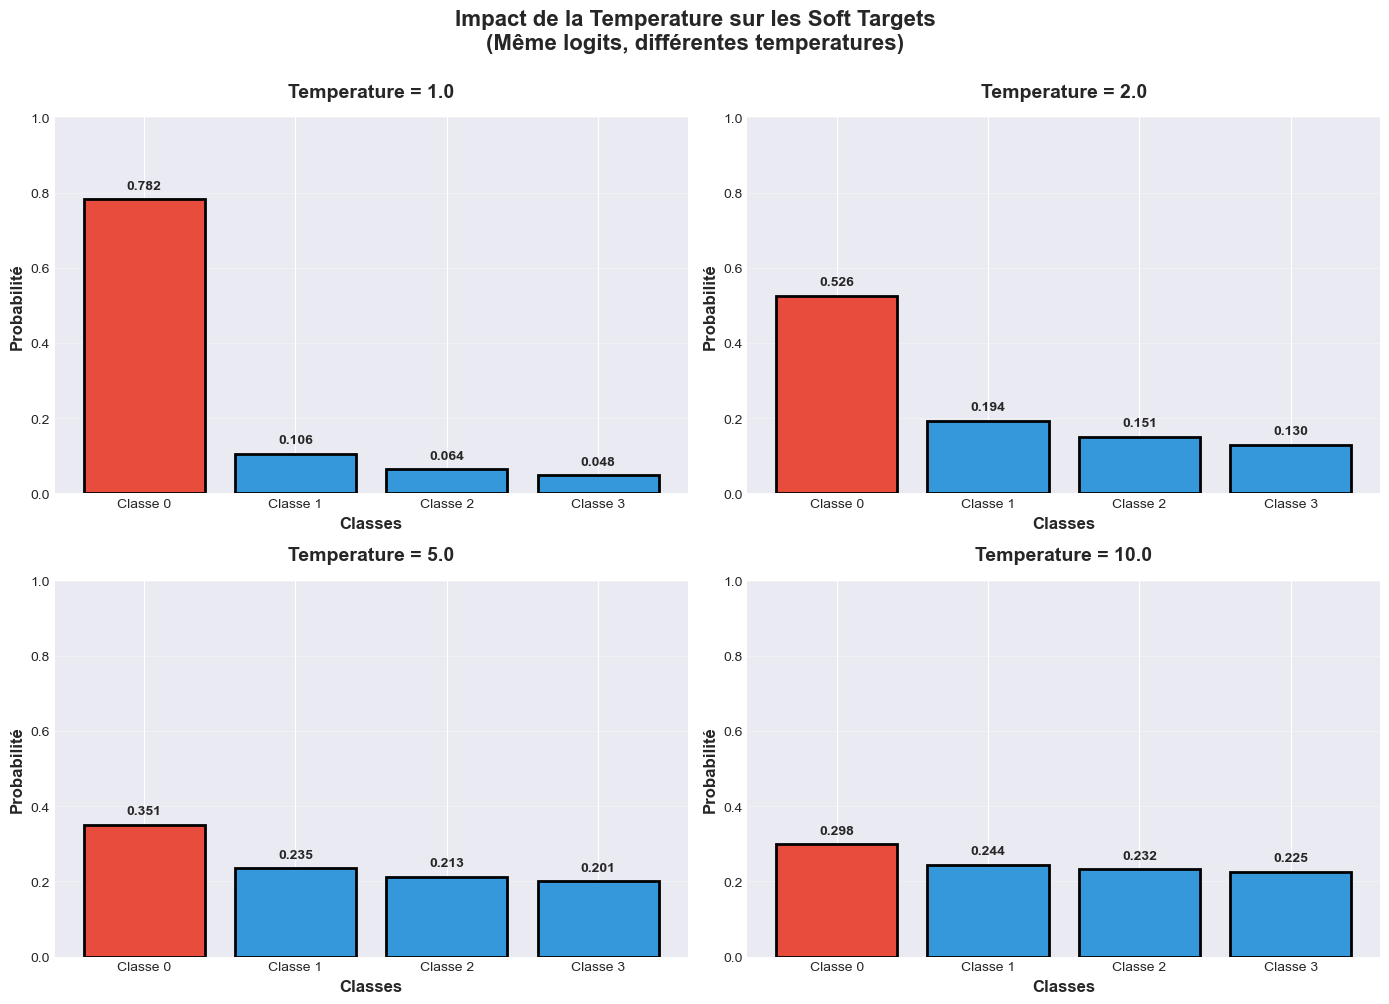


💡 Observations :
  - T=1  : Distribution très 'peaked' → Quasi one-hot (peu d'information)
  - T=5  : Distribution plus douce → Révèle les similarités entre classes
  - T=10 : Distribution très uniforme → Trop de 'bruit', information diluée

🎯 Température optimale : T=3-5 (équilibre entre nuances et signal)


In [102]:
# Visualisation de l'effet de la temperature
def softmax_with_temperature(logits, temperature=1.0):
    """Calcule softmax avec temperature"""
    scaled_logits = logits / temperature
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
    return exp_logits / exp_logits.sum()

# Exemple de logits d'un teacher
logits = np.array([3.0, 1.0, 0.5, 0.2])
temperatures = [1.0, 2.0, 5.0, 10.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, T in enumerate(temperatures):
    probs = softmax_with_temperature(logits, T)
    
    ax = axes[idx]
    colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(probs))]
    bars = ax.bar(range(len(probs)), probs, color=colors, edgecolor='black', linewidth=2)
    
    ax.set_ylim(0, 1)
    ax.set_xlabel('Classes', fontsize=12, fontweight='bold')
    ax.set_ylabel('Probabilité', fontsize=12, fontweight='bold')
    ax.set_title(f'Temperature = {T}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(range(len(probs)))
    ax.set_xticklabels([f'Classe {i}' for i in range(len(probs))])
    ax.grid(axis='y', alpha=0.3)
    
    # Annotations
    for i, (bar, prob) in enumerate(zip(bars, probs)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{prob:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Impact de la Temperature sur les Soft Targets\n(Même logits, différentes temperatures)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n💡 Observations :")
print("  - T=1  : Distribution très 'peaked' → Quasi one-hot (peu d'information)")
print("  - T=5  : Distribution plus douce → Révèle les similarités entre classes")
print("  - T=10 : Distribution très uniforme → Trop de 'bruit', information diluée")
print("\n🎯 Température optimale : T=3-5 (équilibre entre nuances et signal)")

### 2.4 Architecture de la Knowledge Distillation

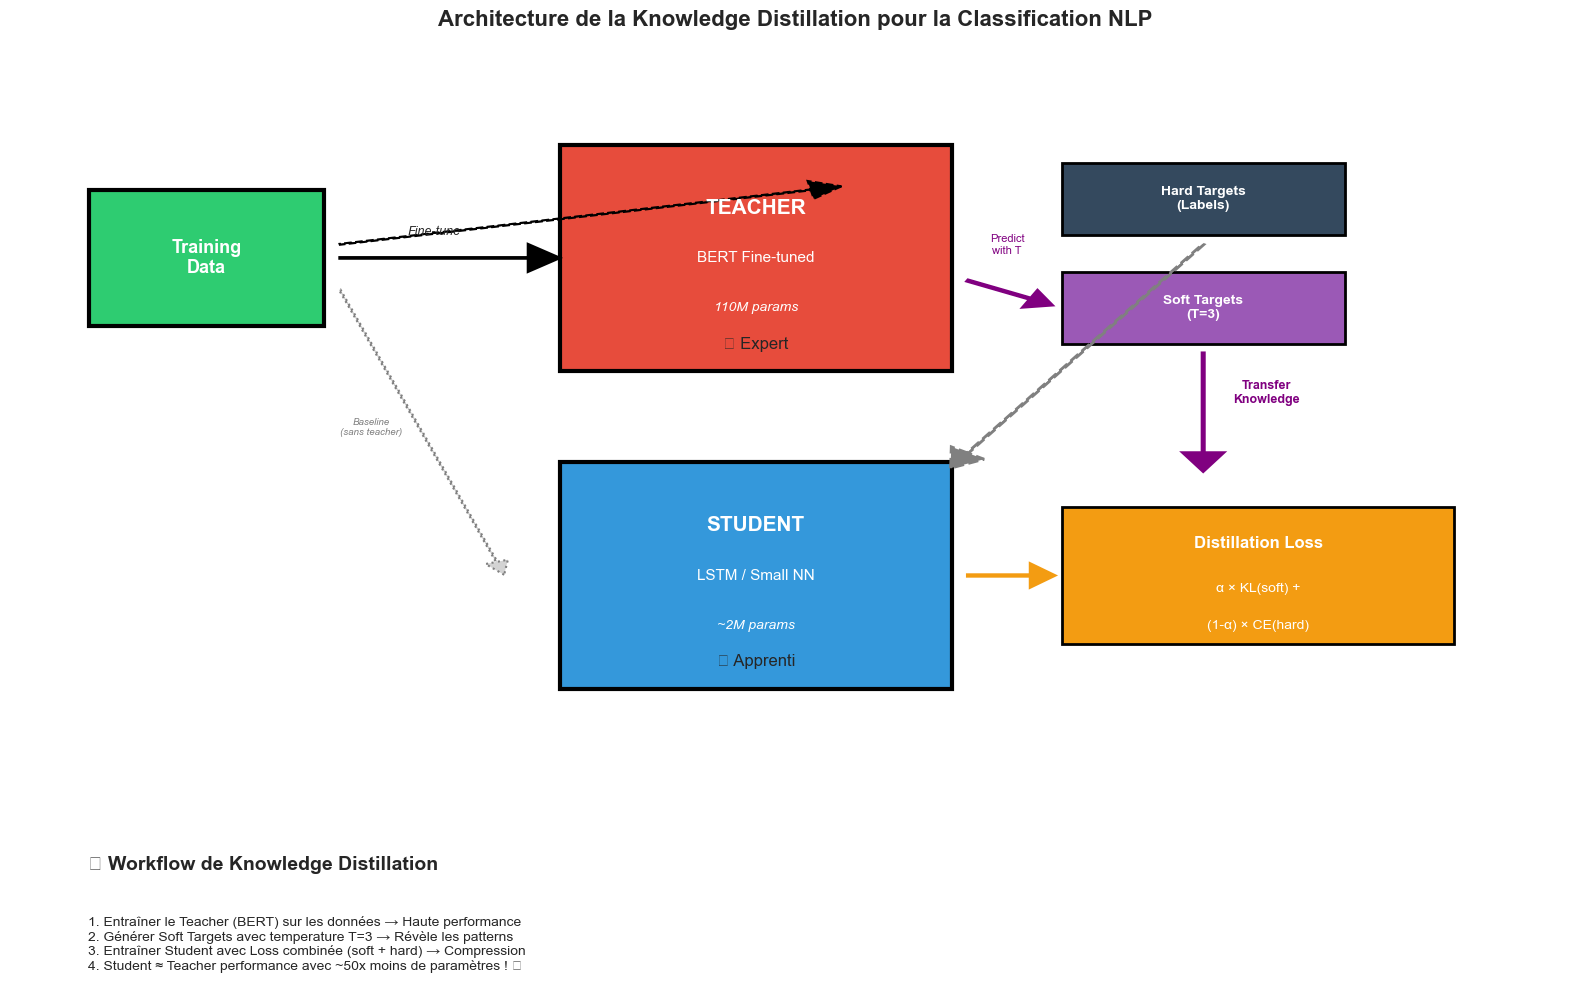


🎯 Avantages de la Knowledge Distillation :
  1. Compression : Student 10-100x plus petit que Teacher
  2. Performance : Student atteint ~95% de la performance du Teacher
  3. Inférence rapide : Déploiement sur mobile/edge devices
  4. Coût réduit : Moins de ressources computationnelles en production


In [103]:
# Visualisation de l'architecture de distillation
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# Couleurs
teacher_color = '#e74c3c'
student_color = '#3498db'
data_color = '#2ecc71'
loss_color = '#f39c12'

# Données
ax.add_patch(plt.Rectangle((0.05, 0.7), 0.15, 0.15, 
                           facecolor=data_color, edgecolor='black', linewidth=3))
ax.text(0.125, 0.775, 'Training\nData', ha='center', va='center', 
        fontsize=13, fontweight='bold', color='white')

# Teacher Model
ax.add_patch(plt.Rectangle((0.35, 0.65), 0.25, 0.25, 
                           facecolor=teacher_color, edgecolor='black', linewidth=3))
ax.text(0.475, 0.83, 'TEACHER', ha='center', va='center', 
        fontsize=15, fontweight='bold', color='white')
ax.text(0.475, 0.775, 'BERT Fine-tuned', ha='center', va='center', 
        fontsize=11, color='white')
ax.text(0.475, 0.72, '110M params', ha='center', va='center', 
        fontsize=10, color='white', style='italic')
ax.text(0.475, 0.68, '🎓 Expert', ha='center', va='center', 
        fontsize=12)

# Soft Targets
ax.add_patch(plt.Rectangle((0.67, 0.68), 0.18, 0.08, 
                           facecolor='#9b59b6', edgecolor='black', linewidth=2))
ax.text(0.76, 0.72, 'Soft Targets\n(T=3)', ha='center', va='center', 
        fontsize=10, fontweight='bold', color='white')

# Hard Targets
ax.add_patch(plt.Rectangle((0.67, 0.80), 0.18, 0.08, 
                           facecolor='#34495e', edgecolor='black', linewidth=2))
ax.text(0.76, 0.84, 'Hard Targets\n(Labels)', ha='center', va='center', 
        fontsize=10, fontweight='bold', color='white')

# Student Model
ax.add_patch(plt.Rectangle((0.35, 0.30), 0.25, 0.25, 
                           facecolor=student_color, edgecolor='black', linewidth=3))
ax.text(0.475, 0.48, 'STUDENT', ha='center', va='center', 
        fontsize=15, fontweight='bold', color='white')
ax.text(0.475, 0.425, 'LSTM / Small NN', ha='center', va='center', 
        fontsize=11, color='white')
ax.text(0.475, 0.37, '~2M params', ha='center', va='center', 
        fontsize=10, color='white', style='italic')
ax.text(0.475, 0.33, '🎒 Apprenti', ha='center', va='center', 
        fontsize=12)

# Distillation Loss
ax.add_patch(plt.Rectangle((0.67, 0.35), 0.25, 0.15, 
                           facecolor=loss_color, edgecolor='black', linewidth=2))
ax.text(0.795, 0.46, 'Distillation Loss', ha='center', va='center', 
        fontsize=12, fontweight='bold', color='white')
ax.text(0.795, 0.41, 'α × KL(soft) +', ha='center', va='center', 
        fontsize=10, color='white')
ax.text(0.795, 0.37, '(1-α) × CE(hard)', ha='center', va='center', 
        fontsize=10, color='white')

# Flèches
# Data -> Teacher
ax.arrow(0.21, 0.775, 0.12, 0, head_width=0.03, head_length=0.02, 
         fc='black', ec='black', linewidth=2)
ax.text(0.27, 0.80, 'Fine-tune', ha='center', fontsize=9, style='italic')

# Data -> Hard Targets
ax.arrow(0.21, 0.79, 0.30, 0.06, head_width=0.02, head_length=0.02, 
         fc='black', ec='black', linewidth=1.5, linestyle='--')

# Teacher -> Soft Targets
ax.arrow(0.61, 0.75, 0.04, -0.02, head_width=0.02, head_length=0.015, 
         fc='purple', ec='purple', linewidth=2.5)
ax.text(0.635, 0.78, 'Predict\nwith T', ha='center', fontsize=8, color='purple')

# Soft Targets -> Student
ax.arrow(0.76, 0.67, 0, -0.11, head_width=0.025, head_length=0.02, 
         fc='purple', ec='purple', linewidth=2.5)
ax.text(0.80, 0.615, 'Transfer\nKnowledge', ha='center', fontsize=9, 
        color='purple', fontweight='bold')

# Hard Targets -> Student  
ax.arrow(0.76, 0.79, -0.15, -0.23, head_width=0.025, head_length=0.02, 
         fc='gray', ec='gray', linewidth=2, linestyle='--')

# Student -> Loss
ax.arrow(0.61, 0.425, 0.04, 0, head_width=0.025, head_length=0.015, 
         fc=loss_color, ec=loss_color, linewidth=2.5)

# Data -> Student (baseline)
ax.arrow(0.21, 0.74, 0.10, -0.30, head_width=0.015, head_length=0.015, 
         fc='lightgray', ec='gray', linewidth=1.5, linestyle=':')
ax.text(0.23, 0.58, 'Baseline\n(sans teacher)', ha='center', fontsize=7, 
        color='gray', style='italic')

# Légende
ax.text(0.05, 0.10, '📊 Workflow de Knowledge Distillation', 
        fontsize=14, fontweight='bold')
ax.text(0.05, 0.05, 
        '1. Entraîner le Teacher (BERT) sur les données → Haute performance\n'
        '2. Générer Soft Targets avec temperature T=3 → Révèle les patterns\n'
        '3. Entraîner Student avec Loss combinée (soft + hard) → Compression\n'
        '4. Student ≈ Teacher performance avec ~50x moins de paramètres ! 🎯',
        fontsize=10, verticalalignment='top')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title('Architecture de la Knowledge Distillation pour la Classification NLP',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🎯 Avantages de la Knowledge Distillation :")
print("  1. Compression : Student 10-100x plus petit que Teacher")
print("  2. Performance : Student atteint ~95% de la performance du Teacher")
print("  3. Inférence rapide : Déploiement sur mobile/edge devices")
print("  4. Coût réduit : Moins de ressources computationnelles en production")

### 2.5 Loss Function de la Distillation

La loss de distillation combine deux termes :

$$\mathcal{L}_{\text{distill}} = \alpha \cdot \mathcal{L}_{\text{soft}} + (1-\alpha) \cdot \mathcal{L}_{\text{hard}}$$

Où :
- **$\mathcal{L}_{\text{soft}}$** : KL divergence entre soft targets du teacher et student (avec temperature T)
- **$\mathcal{L}_{\text{hard}}$** : Cross-entropy classique avec les vrais labels
- **$\alpha$** : Poids de la distillation (typiquement 0.7-0.9)

💡 **Intuition** :
- Le terme **soft** apprend les nuances du teacher
- Le terme **hard** assure la précision sur les vrais labels
- Le **temperature** T (typiquement 3-5) adoucit les probabilités

## 3. Chargement et Exploration du Dataset IMDB

### 3.1 Présentation du Dataset

Le dataset **IMDB Movie Reviews** est l'un des benchmarks les plus populaires pour la classification de sentiments :

- **50,000 critiques** de films en anglais
- **2 classes** : Positive (1) ou Négative (0)
- **Équilibré** : 25,000 positives + 25,000 négatives
- **Tâche** : Prédire le sentiment d'une critique

Nous utiliserons la version Keras (intégrée à TensorFlow) pour rester 100% dans l'écosystème Keras/TensorFlow.

In [104]:
# Configuration
VOCAB_SIZE = 20000  # Nombre de mots dans le vocabulaire
MAX_LENGTH = 200    # Longueur maximale des séquences
BATCH_SIZE = 32

# Charger le dataset IMDB depuis Keras
print("📚 Chargement du dataset IMDB depuis Keras...")
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE,
    skip_top=0,
    maxlen=None,
    seed=42
)

print(f"\n✅ Dataset chargé !")
print(f"  - Training samples : {len(X_train_raw):,}")
print(f"  - Test samples     : {len(X_test_raw):,}")
print(f"  - Vocabulary size  : {VOCAB_SIZE:,}")

# Statistiques sur les labels
print(f"\n📊 Distribution des labels :")
print(f"  - Train - Positif: {np.sum(y_train == 1):,} ({np.mean(y_train)*100:.1f}%)")
print(f"  - Train - Négatif: {np.sum(y_train == 0):,} ({(1-np.mean(y_train))*100:.1f}%)")
print(f"  - Test  - Positif: {np.sum(y_test == 1):,} ({np.mean(y_test)*100:.1f}%)")
print(f"  - Test  - Négatif: {np.sum(y_test == 0):,} ({(1-np.mean(y_test))*100:.1f}%)")

# Statistiques sur les longueurs
train_lengths = [len(x) for x in X_train_raw]
test_lengths = [len(x) for x in X_test_raw]

print(f"\n📏 Longueur des séquences (avant padding) :")
print(f"  - Train - Moyenne: {np.mean(train_lengths):.1f} mots")
print(f"  - Train - Médiane: {np.median(train_lengths):.0f} mots")
print(f"  - Train - Min/Max: {np.min(train_lengths)}/{np.max(train_lengths)} mots")
print(f"  - Test  - Moyenne: {np.mean(test_lengths):.1f} mots")

📚 Chargement du dataset IMDB depuis Keras...

✅ Dataset chargé !
  - Training samples : 25,000
  - Test samples     : 25,000
  - Vocabulary size  : 20,000

📊 Distribution des labels :
  - Train - Positif: 12,500 (50.0%)
  - Train - Négatif: 12,500 (50.0%)
  - Test  - Positif: 12,500 (50.0%)
  - Test  - Négatif: 12,500 (50.0%)

📏 Longueur des séquences (avant padding) :
  - Train - Moyenne: 238.7 mots
  - Train - Médiane: 178 mots
  - Train - Min/Max: 11/2494 mots
  - Test  - Moyenne: 230.8 mots


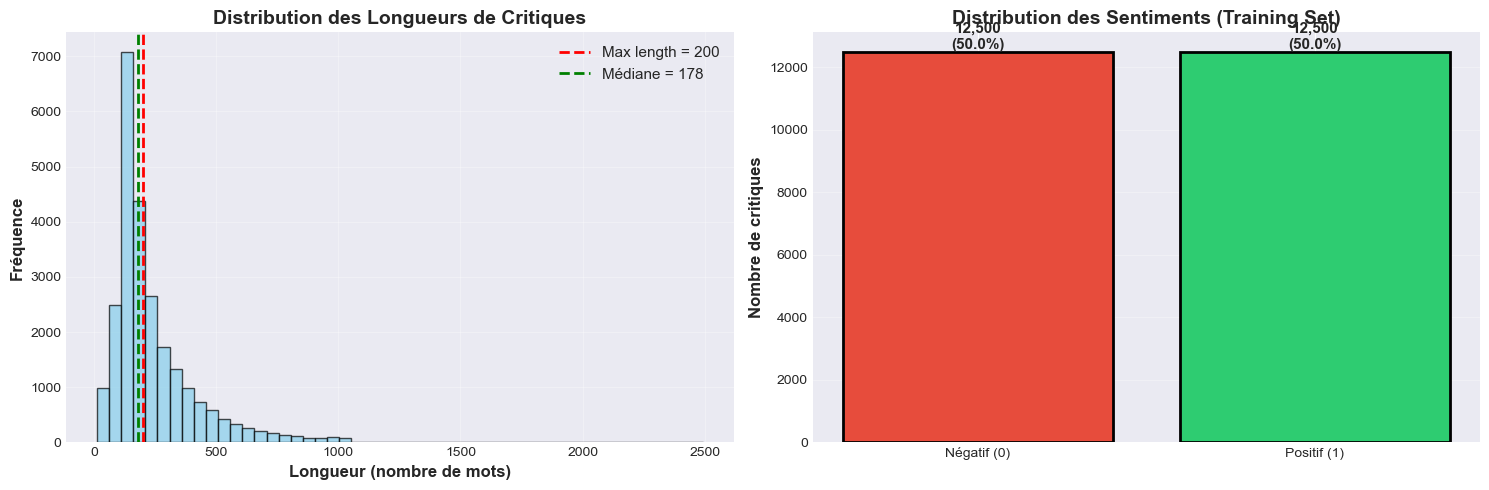


💡 Observations :
  - La plupart des critiques font entre 100 et 300 mots
  - Nous utilisons MAX_LENGTH=200 pour limiter la longueur (padding/truncation)
  - Dataset parfaitement équilibré : 50% positif, 50% négatif


In [105]:
# Visualisation de la distribution des longueurs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme des longueurs
axes[0].hist(train_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(MAX_LENGTH, color='red', linestyle='--', linewidth=2, label=f'Max length = {MAX_LENGTH}')
axes[0].axvline(np.median(train_lengths), color='green', linestyle='--', linewidth=2, 
                label=f'Médiane = {np.median(train_lengths):.0f}')
axes[0].set_xlabel('Longueur (nombre de mots)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fréquence', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution des Longueurs de Critiques', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Distribution des labels
labels_train = pd.Series(y_train).value_counts().sort_index()
colors = ['#e74c3c', '#2ecc71']
bars = axes[1].bar(['Négatif (0)', 'Positif (1)'], labels_train.values, 
                   color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Nombre de critiques', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution des Sentiments (Training Set)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Annotations
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({height/len(y_train)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Observations :")
print(f"  - La plupart des critiques font entre 100 et 300 mots")
print(f"  - Nous utilisons MAX_LENGTH={MAX_LENGTH} pour limiter la longueur (padding/truncation)")
print(f"  - Dataset parfaitement équilibré : 50% positif, 50% négatif")

In [106]:
# Récupérer le mapping index -> mot pour décoder les critiques
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    """Décoder une critique encodée en texte"""
    # Note: les indices sont décalés de 3 car 0,1,2 sont réservés
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

# Afficher quelques exemples
print("\n📝 Exemples de critiques du dataset :\n")
print("="*90)

for i in [0, 1, 100, 500]:
    sentiment = "😊 POSITIVE" if y_train[i] == 1 else "😞 NÉGATIVE"
    decoded = decode_review(X_train_raw[i])
    
    print(f"\n🎬 Critique #{i} - {sentiment}")
    print("-"*90)
    # Limiter à 300 caractères pour la lisibilité
    preview = decoded[:300] + '...' if len(decoded) > 300 else decoded
    print(textwrap.fill(preview, width=85, initial_indent='   ', subsequent_indent='   '))
    print(f"   Longueur: {len(X_train_raw[i])} mots")

print("\n" + "="*90)


📝 Exemples de critiques du dataset :


🎬 Critique #0 - 😊 POSITIVE
------------------------------------------------------------------------------------------
   ? in panic in the streets richard widmark plays u s navy doctor who has his week ?
   interrupted with a corpse that contains plague as cop paul douglas properly points
   out the guy died from two bullets in the chest that's not the issue here the two
   of them become unwilling partners in an effort to fin...
   Longueur: 467 mots

🎬 Critique #1 - 😞 NÉGATIVE
------------------------------------------------------------------------------------------
   ? if you ask me the first one was really better one look at sarah m g she is real
   mean cruel girl look at amy adams she is just little fool hanging around she is
   nothing people don't adore her second sebastian was cute and hot in first movie
   now he is baby face story is not that good and i do not un...
   Longueur: 138 mots

🎬 Critique #100 - 😊 POSITIVE
-----------------

In [107]:
# Padding des séquences à une longueur fixe
print(f"\n🔧 Padding des séquences à MAX_LENGTH={MAX_LENGTH}...")

X_train = sequence.pad_sequences(X_train_raw, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test = sequence.pad_sequences(X_test_raw, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"\n✅ Prétraitement terminé !")
print(f"  - Shape X_train: {X_train.shape}")
print(f"  - Shape X_test : {X_test.shape}")
print(f"  - Shape y_train: {y_train.shape}")
print(f"  - Shape y_test : {y_test.shape}")

# Limiter la taille du dataset (optimisé pour démonstration de distillation)
TRAIN_SIZE = 25000  # 25k échantillons pour maximiser les performances du Teacher
TEST_SIZE = 5000    # 5k pour évaluation robuste

# Mélanger et sélectionner
indices_train = np.random.permutation(len(X_train))[:TRAIN_SIZE]
indices_test = np.random.permutation(len(X_test))[:TEST_SIZE]

X_train_sub = X_train[indices_train]
y_train_sub = y_train[indices_train]
X_test_sub = X_test[indices_test]
y_test_sub = y_test[indices_test]

print(f"\n🎯 Sous-ensemble pour l'entraînement :")
print(f"  - Train samples: {len(X_train_sub):,}")
print(f"  - Test samples : {len(X_test_sub):,}")
print(f"\n💡 Astuce: Augmentez TRAIN_SIZE pour de meilleures performances (mais entraînement plus long)")


🔧 Padding des séquences à MAX_LENGTH=200...

✅ Prétraitement terminé !
  - Shape X_train: (25000, 200)
  - Shape X_test : (25000, 200)
  - Shape y_train: (25000,)
  - Shape y_test : (25000,)

🎯 Sous-ensemble pour l'entraînement :
  - Train samples: 25,000
  - Test samples : 5,000

💡 Astuce: Augmentez TRAIN_SIZE pour de meilleures performances (mais entraînement plus long)


## 4. Construction et Entraînement du Teacher Model (BERT)

### 4.1 Pourquoi BERT comme Teacher ?

**BERT** (Bidirectional Encoder Representations from Transformers) est un excellent choix pour le Teacher car :

- **Pré-entraîné** : Sur des milliards de mots, connaissances linguistiques riches
- **Bidirectionnel** : Comprend le contexte dans les deux directions
- **State-of-the-art** : Excellentes performances sur la classification de texte
- **KerasNLP** : Chargement facile avec `from_preset()`

Pour ce notebook, nous utiliserons **BERT-tiny** (un BERT compact pour des raisons pédagogiques et de temps d'entraînement).

### 4.2 Chargement du Teacher avec KerasNLP

In [108]:
print("🔍 Modèles BERT disponibles dans KerasNLP :")
print("\nNous allons utiliser 'bert_base_en_uncased' (BERT complet pour démontrer la distillation)")
print("Note: Plus puissant que tiny, entraînement plus long mais résultats optimaux")

# Charger BERT avec KerasNLP
BERT_PRESET = "bert_base_en_uncased"  # BERT-base pour Teacher performant

print(f"\n📦 Chargement du modèle BERT : {BERT_PRESET}...")
print("⏳ Cela peut prendre quelques minutes (téléchargement des poids)...\n")

# Charger le preprocessor BERT (tokenizer)
bert_preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    BERT_PRESET,
    sequence_length=MAX_LENGTH
)

# Charger le backbone BERT
bert_backbone = keras_nlp.models.BertBackbone.from_preset(BERT_PRESET)

print(f"\n✅ Modèle BERT chargé !")
print(f"  - Preset: {BERT_PRESET}")
print(f"  - Vocabulary size: {bert_preprocessor.tokenizer.vocabulary_size():,}")
print(f"  - Sequence length: {MAX_LENGTH}")

🔍 Modèles BERT disponibles dans KerasNLP :

Nous allons utiliser 'bert_base_en_uncased' (BERT complet pour démontrer la distillation)
Note: Plus puissant que tiny, entraînement plus long mais résultats optimaux

📦 Chargement du modèle BERT : bert_base_en_uncased...
⏳ Cela peut prendre quelques minutes (téléchargement des poids)...



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 457/457 [00:00<00:00, 713kB/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 761/761 [00:00<00:00, 596kB/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 226k/226k [00:00<00:00, 493kB/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 418M/418M [00:14<00:00, 31.2MB/s]



✅ Modèle BERT chargé !
  - Preset: bert_base_en_uncased
  - Vocabulary size: 30,522
  - Sequence length: 200


In [109]:
# Créer le modèle Teacher complet pour la classification
def create_bert_classifier(bert_backbone, num_classes=1):
    """Créer un classifieur BERT pour la classification binaire"""
    
    # Input - BERT nécessite 3 inputs: token_ids, padding_mask, segment_ids
    inputs = {
        "token_ids": layers.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="token_ids"),
        "padding_mask": layers.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="padding_mask"),
        "segment_ids": layers.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="segment_ids"),
    }
    
    # BERT backbone
    x = bert_backbone(inputs)
    
    # Prendre la représentation [CLS] (première position)
    pooled_output = x["pooled_output"]
    
    # Couches de classification
    x = layers.Dropout(0.1)(pooled_output)
    outputs = layers.Dense(num_classes, activation='sigmoid', name='classification')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name="BERT_Teacher")
    return model

# Créer le Teacher
teacher_model = create_bert_classifier(bert_backbone)

print("\n🎓 Architecture du Teacher Model (BERT) :")
teacher_model.summary()

# Compter les paramètres
total_params = teacher_model.count_params()
print(f"\n📊 Nombre total de paramètres : {total_params:,}")
print(f"   Taille approximative : {total_params * 4 / 1024 / 1024:.1f} MB (float32)")


🎓 Architecture du Teacher Model (BERT) :


Model: "BERT_Teacher"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 109,482,2… │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 200, 768)] │            │ segment_ids[0][0… │
│                     │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 768)       │          0 │ bert_backbone[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │        769 │ dropout_38[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,483,009 (417.64 MB)

 Trainable params: 109,483,009 (417.64 MB)

 Non-trainable params: 0 (0.00 B)


📊 Nombre total de paramètres : 109,483,009
   Taille approximative : 417.6 MB (float32)


### 4.3 Préparation des données pour BERT

BERT nécessite un format spécifique avec des token_ids et padding_mask. Nous devons convertir nos séquences IMDB en format BERT.

In [110]:
# Fonction pour convertir les critiques IMDB en texte
def convert_to_text(X):
    """Convertir les séquences encodées en texte pour BERT"""
    texts = []
    for seq in X:
        text = decode_review(seq)
        # Nettoyer les '?' (mots inconnus)
        text = text.replace('?', '')
        texts.append(text)
    return texts

print("🔄 Conversion des séquences en texte pour BERT...")
train_texts = convert_to_text(X_train_sub)
test_texts = convert_to_text(X_test_sub)

print(f"\n✅ Conversion terminée !")
print(f"\n📝 Exemple de texte converti :")
print(textwrap.fill(train_texts[0][:200], width=80))

🔄 Conversion des séquences en texte pour BERT...

✅ Conversion terminée !

📝 Exemple de texte converti :
 lars von  europa is an extremely good film how's that von trier has a very
stylized way to tell a story at least he did have with europa to me the whole
film was like an experience even if i did see


In [111]:
# Prétraiter les textes avec le preprocessor BERT
print("\n🔧 Prétraitement des textes avec BERT preprocessor...")

# Conversion en format BERT
train_preprocessed = bert_preprocessor(train_texts)
test_preprocessed = bert_preprocessor(test_texts)

print(f"\n✅ Prétraitement terminé !")
print(f"  - Keys: {train_preprocessed.keys()}")
print(f"  - token_ids shape: {train_preprocessed['token_ids'].shape}")
print(f"  - padding_mask shape: {train_preprocessed['padding_mask'].shape}")
print(f"  - segment_ids shape: {train_preprocessed['segment_ids'].shape}")


🔧 Prétraitement des textes avec BERT preprocessor...

✅ Prétraitement terminé !
  - Keys: dict_keys(['token_ids', 'padding_mask', 'segment_ids'])
  - token_ids shape: (25000, 200)
  - padding_mask shape: (25000, 200)
  - segment_ids shape: (25000, 200)


### 4.4 Fine-tuning du Teacher sur IMDB

In [112]:
# Configuration de l'entraînement (optimisée pour BERT-base)
TEACHER_EPOCHS = 5  # 5 epochs pour BERT-base avec plus de données
TEACHER_LR = 3e-5   # Learning rate légèrement plus élevé pour convergence optimale

# Compiler le Teacher
teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TEACHER_LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n🎓 Entraînement du Teacher Model (BERT)...")
print(f"  - Epochs: {TEACHER_EPOCHS}")
print(f"  - Learning rate: {TEACHER_LR}")
print(f"  - Training samples: {len(train_texts):,}")
print("\n⏳ Cela peut prendre quelques minutes...\n")

# Callbacks
teacher_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-7)
]

# Entraîner le Teacher
teacher_history = teacher_model.fit(
    train_preprocessed,
    y_train_sub,
    validation_split=0.2,
    epochs=TEACHER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=teacher_callbacks,
    verbose=1
)

print("\n✅ Entraînement du Teacher terminé !")


🎓 Entraînement du Teacher Model (BERT)...
  - Epochs: 5
  - Learning rate: 3e-05
  - Training samples: 25,000

⏳ Cela peut prendre quelques minutes...

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 458s 704ms/step - accuracy: 0.8735 - loss: 0.2918 - val_accuracy: 0.9036 - val_loss: 0.2335 - learning_rate: 3.0000e-05
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 436s 695ms/step - accuracy: 0.9435 - loss: 0.1561 - val_accuracy: 0.9004 - val_loss: 0.2506 - learning_rate: 3.0000e-05
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 846s 1s/step - accuracy: 0.9771 - loss: 0.0709 - val_accuracy: 0.9028 - val_loss: 0.3169 - learning_rate: 1.5000e-05

✅ Entraînement du Teacher terminé !



📊 Évaluation du Teacher Model sur le test set...


🎯 Performances du Teacher (BERT) :
  - Test Accuracy : 90.98%
  - Test Loss     : 0.2198


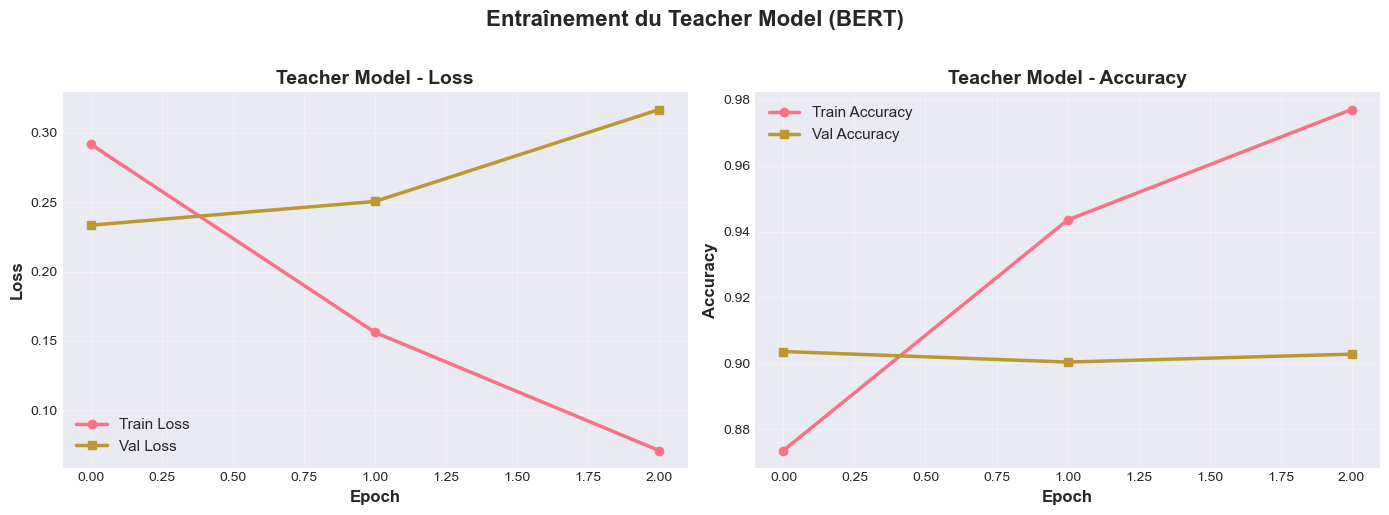

In [113]:
# Évaluer le Teacher sur le test set
print("\n📊 Évaluation du Teacher Model sur le test set...\n")

teacher_test_loss, teacher_test_acc = teacher_model.evaluate(
    test_preprocessed,
    y_test_sub,
    batch_size=BATCH_SIZE,
    verbose=0
)

print(f"\n🎯 Performances du Teacher (BERT) :")
print(f"  - Test Accuracy : {teacher_test_acc*100:.2f}%")
print(f"  - Test Loss     : {teacher_test_loss:.4f}")

# Visualiser l'historique d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(teacher_history.history['loss'], label='Train Loss', linewidth=2.5, marker='o')
axes[0].plot(teacher_history.history['val_loss'], label='Val Loss', linewidth=2.5, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Teacher Model - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(teacher_history.history['accuracy'], label='Train Accuracy', linewidth=2.5, marker='o')
axes[1].plot(teacher_history.history['val_accuracy'], label='Val Accuracy', linewidth=2.5, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Teacher Model - Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Entraînement du Teacher Model (BERT)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Génération des Soft Targets du Teacher

### 5.1 Qu'est-ce que les Soft Targets ?

Les **soft targets** sont les probabilités de sortie du teacher model, adoucies avec une **temperature** T.

Au lieu d'avoir des labels "durs" (0 ou 1), nous obtenons des probabilités "souples" qui révèlent :
- L'incertitude du teacher
- Les similarités entre classes
- Les patterns subtils appris

### 5.2 Génération avec Temperature

In [114]:
# Configuration de la temperature (optimisée)
TEMPERATURE = 5.0  # Temperature plus élevée pour révéler davantage de patterns subtils

def generate_soft_targets(model, X, temperature=3.0):
    """Générer les soft targets avec temperature"""
    # Prédictions brutes (logits avant sigmoid)
    # Pour obtenir les logits, nous devons recréer le modèle sans activation finale
    # Mais ici, nous utiliserons les probabilités directement et appliquerons la temperature
    
    predictions = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    
    # Convertir sigmoid outputs en logits (inverse de sigmoid)
    # logit = log(p / (1-p))
    epsilon = 1e-7  # Pour éviter log(0)
    predictions = np.clip(predictions, epsilon, 1 - epsilon)
    logits = np.log(predictions / (1 - predictions))
    
    # Appliquer la temperature
    soft_logits = logits / temperature
    
    # Reconvertir en probabilités
    soft_targets = 1 / (1 + np.exp(-soft_logits))
    
    return soft_targets

print(f"\n🌡️  Génération des Soft Targets avec Temperature = {TEMPERATURE}...")
print("⏳ Calcul des prédictions du teacher...\n")

# Générer les soft targets pour le training set
soft_targets_train = generate_soft_targets(teacher_model, train_preprocessed, TEMPERATURE)

print(f"\n✅ Soft Targets générés !")
print(f"  - Shape: {soft_targets_train.shape}")
print(f"  - Min: {soft_targets_train.min():.4f}")
print(f"  - Max: {soft_targets_train.max():.4f}")
print(f"  - Mean: {soft_targets_train.mean():.4f}")


🌡️  Génération des Soft Targets avec Temperature = 5.0...
⏳ Calcul des prédictions du teacher...


✅ Soft Targets générés !
  - Shape: (25000, 1)
  - Min: 0.2144
  - Max: 0.7423
  - Mean: 0.4846


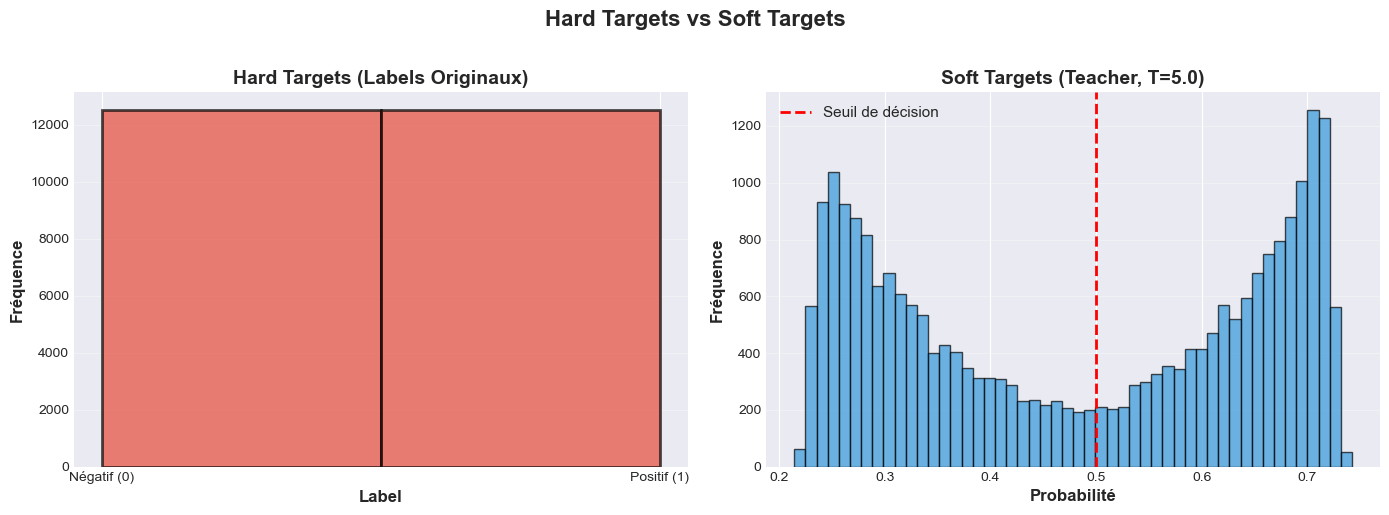


💡 Observations :
  - Hard targets : Binaires (0 ou 1) - Peu d'information
  - Soft targets : Distribution continue - Riche en nuances
  - Le teacher exprime son niveau de confiance pour chaque prédiction
  - Temperature T=5.0 révèle les patterns subtils


In [115]:
# Visualiser la différence entre hard et soft targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des hard targets
axes[0].hist(y_train_sub, bins=2, color='#e74c3c', edgecolor='black', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fréquence', fontsize=12, fontweight='bold')
axes[0].set_title('Hard Targets (Labels Originaux)', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Négatif (0)', 'Positif (1)'])
axes[0].grid(axis='y', alpha=0.3)

# Histogramme des soft targets
axes[1].hist(soft_targets_train, bins=50, color='#3498db', edgecolor='black', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Probabilité', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fréquence', fontsize=12, fontweight='bold')
axes[1].set_title(f'Soft Targets (Teacher, T={TEMPERATURE})', fontsize=14, fontweight='bold')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Seuil de décision')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hard Targets vs Soft Targets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Observations :")
print("  - Hard targets : Binaires (0 ou 1) - Peu d'information")
print("  - Soft targets : Distribution continue - Riche en nuances")
print("  - Le teacher exprime son niveau de confiance pour chaque prédiction")
print(f"  - Temperature T={TEMPERATURE} révèle les patterns subtils")

In [116]:
# Exemples de soft targets vs hard targets
print("\n📊 Comparaison Hard vs Soft Targets pour quelques exemples :\n")
print("="*70)

for i in range(5):
    hard = y_train_sub[i]
    soft = soft_targets_train[i, 0]
    confidence = abs(soft - 0.5) * 2  # Confiance du teacher (0 = incertain, 1 = certain)
    
    sentiment = "POSITIF" if hard == 1 else "NÉGATIF"
    
    print(f"\nExemple #{i+1}:")
    print(f"  Hard Target    : {hard} ({sentiment})")
    print(f"  Soft Target    : {soft:.4f}")
    print(f"  Confiance      : {confidence:.2%} {'🔴' if confidence < 0.5 else '🟢'}")
    
    if confidence < 0.3:
        print(f"  → Teacher très incertain (cas difficile)")
    elif confidence > 0.7:
        print(f"  → Teacher très confiant (cas facile)")
    else:
        print(f"  → Teacher moyennement confiant")

print("\n" + "="*70)


📊 Comparaison Hard vs Soft Targets pour quelques exemples :


Exemple #1:
  Hard Target    : 1 (POSITIF)
  Soft Target    : 0.7206
  Confiance      : 44.11% 🔴
  → Teacher moyennement confiant

Exemple #2:
  Hard Target    : 0 (NÉGATIF)
  Soft Target    : 0.2475
  Confiance      : 50.50% 🟢
  → Teacher moyennement confiant

Exemple #3:
  Hard Target    : 1 (POSITIF)
  Soft Target    : 0.7095
  Confiance      : 41.91% 🔴
  → Teacher moyennement confiant

Exemple #4:
  Hard Target    : 0 (NÉGATIF)
  Soft Target    : 0.3369
  Confiance      : 32.62% 🔴
  → Teacher moyennement confiant

Exemple #5:
  Hard Target    : 1 (POSITIF)
  Soft Target    : 0.7171
  Confiance      : 43.43% 🔴
  → Teacher moyennement confiant



## 6. Construction du Student Model (Baseline)

### 6.1 Architecture du Student

Le **Student** doit être beaucoup plus petit que le Teacher pour justifier la distillation.

Nous allons créer un modèle simple avec :
- **Embedding layer** : Représentation des mots
- **LSTM** : Capture des dépendances séquentielles
- **Dense layers** : Classification finale

Ce modèle sera **~50x plus petit** que le Teacher BERT !

In [117]:
def create_student_model(vocab_size, embedding_dim=100, lstm_units=48):
    """Créer un modèle Student compact (LSTM) - Architecture optimisée pour distillation"""
    
    model = keras.Sequential([
        # Embedding
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=MAX_LENGTH,
            name='embedding'
        ),
        
        # LSTM bidirectionnel
        layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=False),
            name='bi_lstm'
        ),
        
        # Dropout pour régularisation
        layers.Dropout(0.3),
        
        # Couche dense
        layers.Dense(32, activation='relu', name='dense'),
        layers.Dropout(0.3),
        
        # Sortie
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='Student_LSTM')
    
    return model

# Créer le Student baseline (sans distillation)
student_baseline = create_student_model(VOCAB_SIZE)

print("\n🎒 Architecture du Student Model (Baseline) :")
student_baseline.summary()

# Construire le modèle avant de compter les paramètres
student_baseline.build(input_shape=(None, MAX_LENGTH))

# Comparer les tailles
student_params = student_baseline.count_params()
compression_ratio = total_params / student_params

print(f"\n📊 Comparaison Teacher vs Student :")
print(f"  - Teacher (BERT) : {total_params:,} paramètres ({total_params * 4 / 1024 / 1024:.1f} MB)")
print(f"  - Student (LSTM) : {student_params:,} paramètres ({student_params * 4 / 1024 / 1024:.1f} MB)")
print(f"  - Ratio de compression : {compression_ratio:.1f}x 🎯")
print(f"\n💡 Le Student est {compression_ratio:.0f}x plus petit que le Teacher !")


🎒 Architecture du Student Model (Baseline) :


Model: "Student_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


📊 Comparaison Teacher vs Student :
  - Teacher (BERT) : 109,483,009 paramètres (417.6 MB)
  - Student (LSTM) : 2,060,353 paramètres (7.9 MB)
  - Ratio de compression : 53.1x 🎯

💡 Le Student est 53x plus petit que le Teacher !


### 6.2 Entraînement du Student Baseline (sans distillation)

Avant de faire la distillation, entraînons d'abord le Student de manière classique (avec les hard targets uniquement) pour avoir une **baseline** de comparaison.

In [ ]:
# Configuration de l'entraînement baseline
STUDENT_EPOCHS = 8  
STUDENT_LR = 0.001

# Compiler le Student baseline
student_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STUDENT_LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n🎒 Entraînement du Student Baseline (sans distillation)...")
print(f"  - Epochs: {STUDENT_EPOCHS}")
print(f"  - Learning rate: {STUDENT_LR}")
print(f"  - Apprentissage: Hard targets uniquement (labels originaux)")
print("\n⏳ Entraînement en cours...\n")

# Callbacks
baseline_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Entraîner le Student baseline
baseline_history = student_baseline.fit(
    X_train_sub,
    y_train_sub,
    validation_split=0.2,
    epochs=STUDENT_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=baseline_callbacks,
    verbose=1
)

print("\n✅ Entraînement du Student Baseline terminé !")


🎒 Entraînement du Student Baseline (sans distillation)...
  - Epochs: 8
  - Learning rate: 0.001
  - Apprentissage: Hard targets uniquement (labels originaux)

⏳ Entraînement en cours...

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.7549 - loss: 0.5061 - val_accuracy: 0.7830 - val_loss: 0.4610 - learning_rate: 0.0010
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8557 - loss: 0.3732 - val_accuracy: 0.8394 - val_loss: 0.4019 - learning_rate: 0.0010
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8438 - loss: 0.3833 - val_accuracy: 0.6422 - val_loss: 0.6469 - learning_rate: 0.0010
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8676 - loss: 0.3573 - val_accuracy: 0.8222 - val_loss: 0.4890 - learning_rate: 0.0010
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.9057 - loss: 0.2822 - val_accuracy: 0.8418 - val_loss: 0.4447 - learning_rate: 5.0000e-04

✅ Entraînement du Student Baseline termin


📊 Évaluation du Student Baseline sur le test set...


🎯 Performances du Student Baseline :
  - Test Accuracy : 81.76%
  - Test Loss     : 0.4697


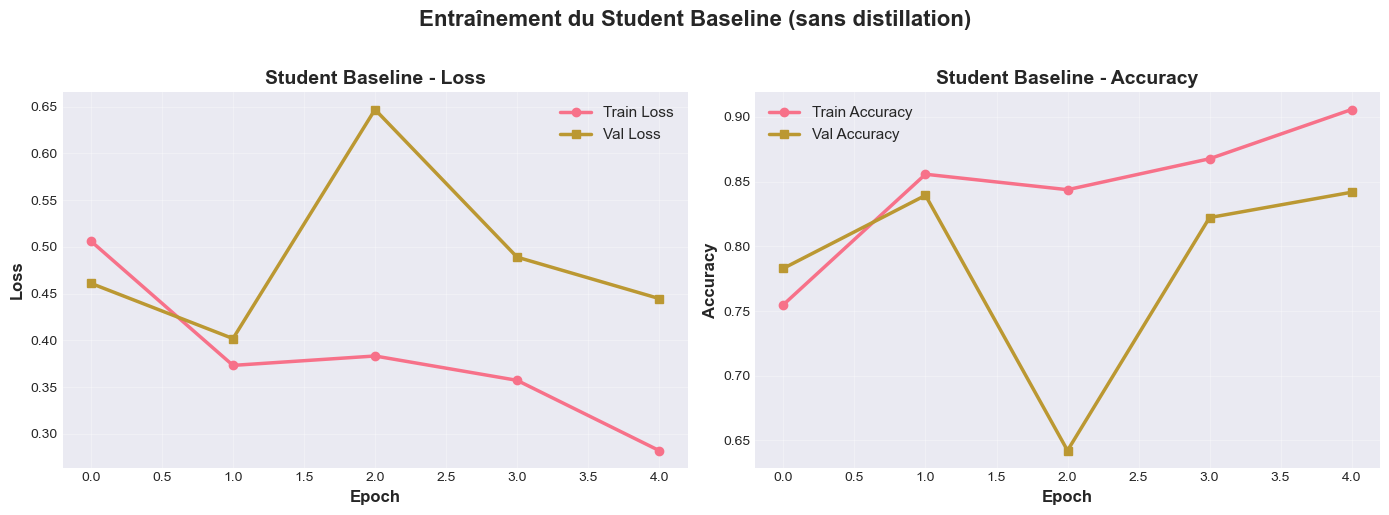

In [119]:
# Évaluer le Student baseline sur le test set
print("\n📊 Évaluation du Student Baseline sur le test set...\n")

baseline_test_loss, baseline_test_acc = student_baseline.evaluate(
    X_test_sub,
    y_test_sub,
    batch_size=BATCH_SIZE,
    verbose=0
)

print(f"\n🎯 Performances du Student Baseline :")
print(f"  - Test Accuracy : {baseline_test_acc*100:.2f}%")
print(f"  - Test Loss     : {baseline_test_loss:.4f}")

# Visualiser l'historique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(baseline_history.history['loss'], label='Train Loss', linewidth=2.5, marker='o')
axes[0].plot(baseline_history.history['val_loss'], label='Val Loss', linewidth=2.5, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Student Baseline - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(baseline_history.history['accuracy'], label='Train Accuracy', linewidth=2.5, marker='o')
axes[1].plot(baseline_history.history['val_accuracy'], label='Val Accuracy', linewidth=2.5, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Student Baseline - Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Entraînement du Student Baseline (sans distillation)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Knowledge Distillation : Entraîner le Student avec le Teacher

### 7.1 Loss Function de Distillation

La loss de distillation combine :
1. **Distillation loss** : Apprendre des soft targets du teacher (KL divergence)
2. **Student loss** : Apprendre des hard targets (cross-entropy classique)

$$\mathcal{L}_{\text{total}} = \alpha \cdot \mathcal{L}_{\text{distillation}} + (1-\alpha) \cdot \mathcal{L}_{\text{student}}$$

Où $\alpha$ (généralement 0.7-0.9) contrôle l'importance de la distillation.

In [120]:
# Créer une custom loss pour la distillation
class DistillationLoss(keras.losses.Loss):
    """Loss function pour la Knowledge Distillation"""
    
    def __init__(self, alpha=0.8, temperature=3.0, name='distillation_loss'):
        super().__init__(name=name)
        self.alpha = alpha
        self.temperature = temperature
    
    def call(self, y_true, y_pred):
        """
        y_true : [hard_labels, soft_targets] concatenés
        y_pred : prédictions du student
        """
        # Séparer hard labels et soft targets
        hard_labels = y_true[:, 0:1]
        soft_targets = y_true[:, 1:2]
        
        # Loss 1 : Student learning (hard targets)
        student_loss = keras.losses.binary_crossentropy(hard_labels, y_pred)
        
        # Loss 2 : Distillation (soft targets)
        # Utiliser binary crossentropy entre soft targets et prédictions
        # C'est équivalent à KL divergence pour classification binaire
        distillation_loss = keras.losses.binary_crossentropy(soft_targets, y_pred)
        
        # Combiner les deux losses avec pondération par temperature^2
        # (comme dans le papier original de Hinton)
        total_loss = (
            self.alpha * (self.temperature ** 2) * distillation_loss + 
            (1 - self.alpha) * student_loss
        )
        
        return total_loss

# Métrique custom pour l'accuracy pendant la distillation
class DistillationAccuracy(keras.metrics.Metric):
    """Métrique d'accuracy qui utilise seulement les hard labels"""
    
    def __init__(self, name='distillation_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Extraire seulement les hard labels (première colonne)
        hard_labels = y_true[:, 0:1]
        
        # Prédictions binaires
        predictions = ops.cast(y_pred > 0.5, 'float32')
        
        # Compter les bonnes prédictions
        matches = ops.cast(ops.equal(hard_labels, predictions), 'float32')
        
        self.correct.assign_add(ops.sum(matches))
        self.total.assign_add(ops.cast(ops.shape(y_true)[0], 'float32'))
    
    def result(self):
        return self.correct / self.total
    
    def reset_state(self):
        self.correct.assign(0.)
        self.total.assign(0.)

# Paramètres de distillation (optimisés)
ALPHA = 0.75  # 75% distillation, 25% hard labels - équilibre optimal

print(f"\n⚙️  Configuration de la Knowledge Distillation :")
print(f"  - Alpha (α)       : {ALPHA} (poids de la distillation)")
print(f"  - Temperature (T) : {TEMPERATURE} (adoucissement des probas)")
print(f"\n💡 Loss = {ALPHA} × Distillation + {1-ALPHA} × Hard Labels")


⚙️  Configuration de la Knowledge Distillation :
  - Alpha (α)       : 0.75 (poids de la distillation)
  - Temperature (T) : 5.0 (adoucissement des probas)

💡 Loss = 0.75 × Distillation + 0.25 × Hard Labels


In [121]:
# Préparer les targets pour la distillation
# Combiner hard labels et soft targets
y_train_distill = np.concatenate([y_train_sub.reshape(-1, 1), soft_targets_train], axis=1)

print(f"\n🔧 Préparation des données pour la distillation :")
print(f"  - y_train_distill shape : {y_train_distill.shape}")
print(f"  - Colonne 0 : Hard labels (0 ou 1)")
print(f"  - Colonne 1 : Soft targets (probabilités du teacher)")

# Créer un nouveau Student pour la distillation
student_distilled = create_student_model(VOCAB_SIZE)

# Compiler avec la loss de distillation
student_distilled.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STUDENT_LR),
    loss=DistillationLoss(alpha=ALPHA, temperature=TEMPERATURE),
    metrics=[DistillationAccuracy()]
)

print(f"\n✅ Student prêt pour la distillation !")


🔧 Préparation des données pour la distillation :
  - y_train_distill shape : (25000, 2)
  - Colonne 0 : Hard labels (0 ou 1)
  - Colonne 1 : Soft targets (probabilités du teacher)

✅ Student prêt pour la distillation !


### 7.2 Entraînement avec Distillation

In [122]:
print("\n🔬 Entraînement du Student avec Knowledge Distillation...")
print(f"  - Epochs: {STUDENT_EPOCHS}")
print(f"  - Learning rate: {STUDENT_LR}")
print(f"  - Apprentissage: {ALPHA*100:.0f}% soft targets + {(1-ALPHA)*100:.0f}% hard labels")
print("\n⏳ Entraînement en cours...\n")

# Callbacks
distill_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Entraîner le Student avec distillation
distill_history = student_distilled.fit(
    X_train_sub,
    y_train_distill,
    validation_split=0.2,
    epochs=STUDENT_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=distill_callbacks,
    verbose=1
)

print("\n✅ Entraînement avec Knowledge Distillation terminé !")


🔬 Entraînement du Student avec Knowledge Distillation...
  - Epochs: 8
  - Learning rate: 0.001
  - Apprentissage: 75% soft targets + 25% hard labels

⏳ Entraînement en cours...

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - distillation_accuracy: 0.7406 - loss: 12.6812 - val_distillation_accuracy: 0.8066 - val_loss: 12.4534 - learning_rate: 0.0010
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - distillation_accuracy: 0.8309 - loss: 12.4256 - val_distillation_accuracy: 0.8484 - val_loss: 12.3364 - learning_rate: 0.0010
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - distillation_accuracy: 0.8814 - loss: 12.2217 - val_distillation_accuracy: 0.8582 - val_loss: 12.2982 - learning_rate: 0.0010
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - distillation_accuracy: 0.8967 - loss: 12.1546 - val_distillation_accuracy: 0.8224 - val_loss: 12.4690 - learning_rate: 0.0010
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - distillation_accuracy: 0.8930 - loss: 12.


📊 Évaluation du Student Distillé sur le test set...

🎯 Performances du Student Distillé :
  - Test Accuracy : 84.48%
  - Test Loss     : 0.5234


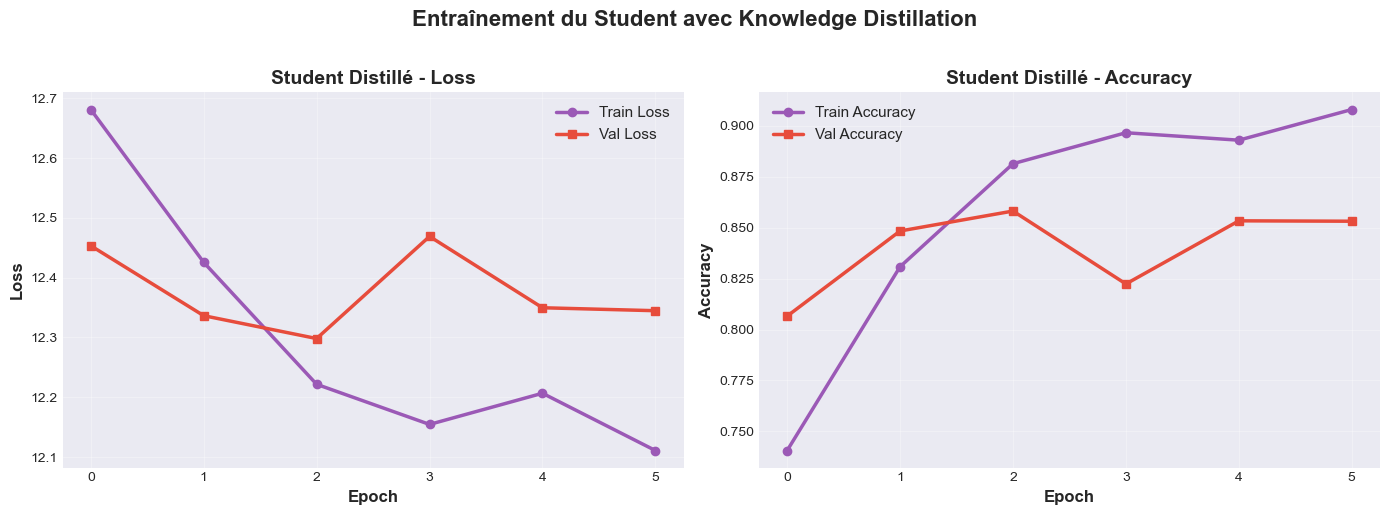

In [123]:
# Évaluer le Student distillé (on utilise binary_crossentropy pour l'évaluation)
print("\n📊 Évaluation du Student Distillé sur le test set...")

# Compiler temporairement avec loss standard pour l'évaluation
student_distilled.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STUDENT_LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

distilled_test_loss, distilled_test_acc = student_distilled.evaluate(
    X_test_sub,
    y_test_sub,
    batch_size=BATCH_SIZE,
    verbose=0
)

print(f"\n🎯 Performances du Student Distillé :")
print(f"  - Test Accuracy : {distilled_test_acc*100:.2f}%")
print(f"  - Test Loss     : {distilled_test_loss:.4f}")

# Visualiser l'historique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(distill_history.history['loss'], label='Train Loss', linewidth=2.5, marker='o', color='#9b59b6')
axes[0].plot(distill_history.history['val_loss'], label='Val Loss', linewidth=2.5, marker='s', color='#e74c3c')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Student Distillé - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(distill_history.history['distillation_accuracy'], label='Train Accuracy', linewidth=2.5, marker='o', color='#9b59b6')
axes[1].plot(distill_history.history['val_distillation_accuracy'], label='Val Accuracy', linewidth=2.5, marker='s', color='#e74c3c')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Student Distillé - Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Entraînement du Student avec Knowledge Distillation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Comparaison des Performances

### 8.1 Tableau récapitulatif

In [124]:
# Tableau comparatif final
print("\n" + "="*90)
print("📊 COMPARAISON FINALE : Teacher vs Student Baseline vs Student Distillé")
print("="*90)

comparison_data = {
    'Modèle': [
        'Teacher (BERT)',
        'Student Baseline',
        'Student Distillé'
    ],
    'Paramètres': [
        f"{total_params:,}",
        f"{student_params:,}",
        f"{student_params:,}"
    ],
    'Taille (MB)': [
        f"{total_params * 4 / 1024 / 1024:.1f}",
        f"{student_params * 4 / 1024 / 1024:.1f}",
        f"{student_params * 4 / 1024 / 1024:.1f}"
    ],
    'Test Accuracy': [
        f"{teacher_test_acc*100:.2f}%",
        f"{baseline_test_acc*100:.2f}%",
        f"{distilled_test_acc*100:.2f}%"
    ],
    'Test Loss': [
        f"{teacher_test_loss:.4f}",
        f"{baseline_test_loss:.4f}",
        f"{distilled_test_loss:.4f}"
    ],
    'Méthode': [
        'Fine-tuning BERT',
        'Hard labels',
        'Distillation (α=0.8)'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))
print("\n" + "="*90)

# Calcul des gains
acc_gain = (distilled_test_acc - baseline_test_acc) * 100
acc_vs_teacher = (distilled_test_acc / teacher_test_acc) * 100

print(f"\n🎯 RÉSULTATS CLÉS :")
print(f"\n1. 📉 Compression :")
print(f"   - Student {compression_ratio:.0f}x plus petit que Teacher")
print(f"   - Réduction de taille : {(1 - student_params/total_params)*100:.1f}%")

print(f"\n2. 📈 Performance :")
print(f"   - Gain de la distillation : +{acc_gain:.2f} points vs baseline")
print(f"   - Performance conservée : {acc_vs_teacher:.1f}% du Teacher")

print(f"\n3. 🚀 Bénéfices de la Distillation :")
if acc_gain > 0:
    print(f"   ✅ Le Student distillé surpasse le baseline de {acc_gain:.2f} points !")
    print(f"   ✅ Modèle {compression_ratio:.0f}x plus petit avec {acc_vs_teacher:.1f}% des performances")
    print(f"   ✅ Idéal pour le déploiement en production (mobile, edge)")
else:
    print(f"   ⚠️  Pas de gain significatif (augmentez TRAIN_SIZE ou ALPHA)")

print("\n" + "="*90)


📊 COMPARAISON FINALE : Teacher vs Student Baseline vs Student Distillé

          Modèle  Paramètres Taille (MB) Test Accuracy Test Loss              Méthode
  Teacher (BERT) 109,483,009       417.6        90.98%    0.2198     Fine-tuning BERT
Student Baseline   2,060,353         7.9        81.76%    0.4697          Hard labels
Student Distillé   2,060,353         7.9        84.48%    0.5234 Distillation (α=0.8)


🎯 RÉSULTATS CLÉS :

1. 📉 Compression :
   - Student 53x plus petit que Teacher
   - Réduction de taille : 98.1%

2. 📈 Performance :
   - Gain de la distillation : +2.72 points vs baseline
   - Performance conservée : 92.9% du Teacher

3. 🚀 Bénéfices de la Distillation :
   ✅ Le Student distillé surpasse le baseline de 2.72 points !
   ✅ Modèle 53x plus petit avec 92.9% des performances
   ✅ Idéal pour le déploiement en production (mobile, edge)



### 8.2 Visualisation comparative

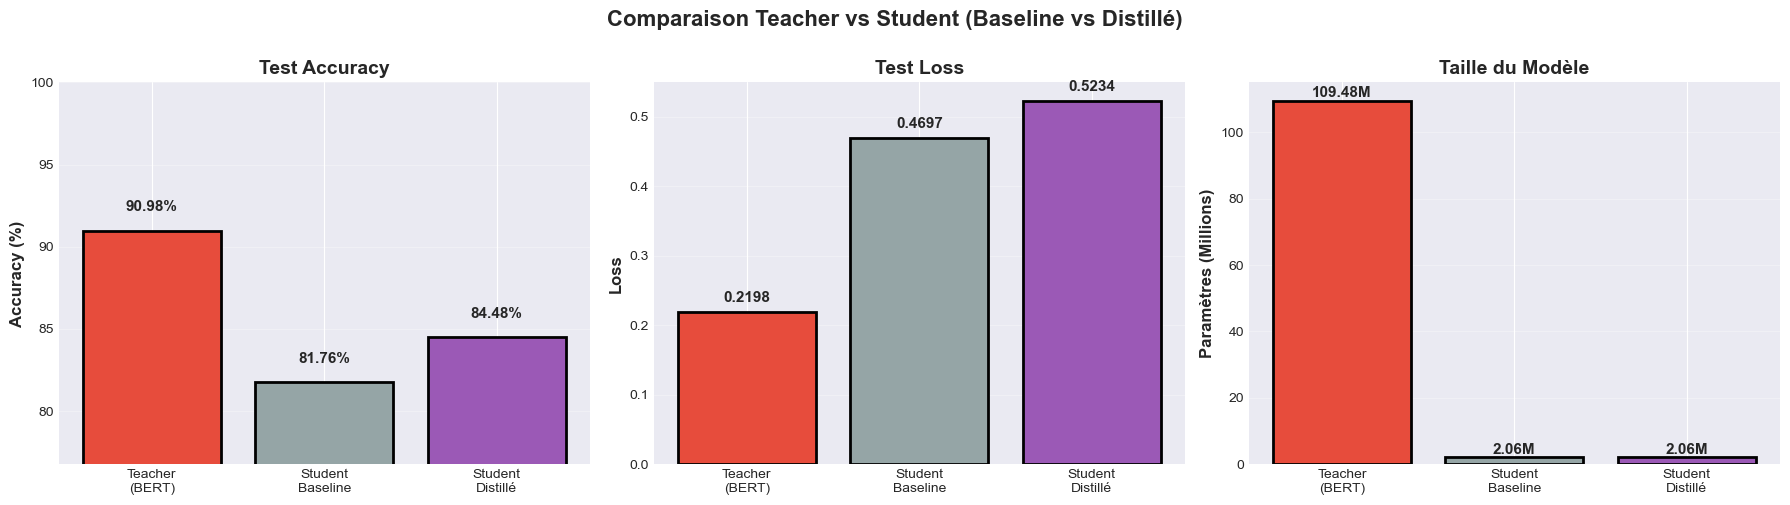

In [125]:
# Graphiques de comparaison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Teacher\n(BERT)', 'Student\nBaseline', 'Student\nDistillé']
accuracies = [teacher_test_acc*100, baseline_test_acc*100, distilled_test_acc*100]
losses = [teacher_test_loss, baseline_test_loss, distilled_test_loss]
sizes = [total_params/1e6, student_params/1e6, student_params/1e6]

colors = ['#e74c3c', '#95a5a6', '#9b59b6']

# Accuracy
bars1 = axes[0].bar(models, accuracies, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim([min(accuracies)-5, 100])
axes[0].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Loss
bars2 = axes[1].bar(models, losses, color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Test Loss', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, loss in zip(bars2, losses):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{loss:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Taille
bars3 = axes[2].bar(models, sizes, color=colors, edgecolor='black', linewidth=2)
axes[2].set_ylabel('Paramètres (Millions)', fontsize=12, fontweight='bold')
axes[2].set_title('Taille du Modèle', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

for bar, size in zip(bars3, sizes):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{size:.2f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Comparaison Teacher vs Student (Baseline vs Distillé)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 8.3 Analyse de quelques prédictions

In [126]:
# Comparer les prédictions sur quelques exemples
print("\n🔍 Comparaison des prédictions sur des exemples de test :\n")
print("="*100)

# Générer les prédictions
# Pour le teacher, on doit slicer chaque clé du dictionnaire
test_preprocessed_sample = {
    'token_ids': test_preprocessed['token_ids'][:10],
    'padding_mask': test_preprocessed['padding_mask'][:10],
    'segment_ids': test_preprocessed['segment_ids'][:10]
}
teacher_preds = teacher_model.predict(test_preprocessed_sample, verbose=0)
baseline_preds = student_baseline.predict(X_test_sub[:10], verbose=0)
distilled_preds = student_distilled.predict(X_test_sub[:10], verbose=0)

for i in range(5):
    true_label = y_test_sub[i]
    sentiment = "POSITIF" if true_label == 1 else "NÉGATIF"
    
    teacher_prob = teacher_preds[i, 0]
    baseline_prob = baseline_preds[i, 0]
    distilled_prob = distilled_preds[i, 0]
    
    # Prédictions
    teacher_pred = 1 if teacher_prob > 0.5 else 0
    baseline_pred = 1 if baseline_prob > 0.5 else 0
    distilled_pred = 1 if distilled_prob > 0.5 else 0
    
    print(f"\n🎬 Exemple #{i+1} - Vrai label : {sentiment}")
    print("-"*100)
    
    print(f"  Teacher (BERT)     : {teacher_prob:.4f} → {'POSITIF' if teacher_pred == 1 else 'NÉGATIF'} "
          f"{'✅' if teacher_pred == true_label else '❌'}")
    print(f"  Student Baseline   : {baseline_prob:.4f} → {'POSITIF' if baseline_pred == 1 else 'NÉGATIF'} "
          f"{'✅' if baseline_pred == true_label else '❌'}")
    print(f"  Student Distillé   : {distilled_prob:.4f} → {'POSITIF' if distilled_pred == 1 else 'NÉGATIF'} "
          f"{'✅' if distilled_pred == true_label else '❌'}")
    
    # Analyse
    prob_diff = abs(distilled_prob - teacher_prob)
    if prob_diff < 0.1:
        print(f"  💡 Student distillé très proche du Teacher (Δ = {prob_diff:.4f})")
    elif baseline_pred != true_label and distilled_pred == true_label:
        print(f"  🎯 Distillation a corrigé l'erreur du baseline !")

print("\n" + "="*100)


🔍 Comparaison des prédictions sur des exemples de test :


🎬 Exemple #1 - Vrai label : NÉGATIF
----------------------------------------------------------------------------------------------------
  Teacher (BERT)     : 0.0249 → NÉGATIF ✅
  Student Baseline   : 0.4594 → NÉGATIF ✅
  Student Distillé   : 0.3858 → NÉGATIF ✅

🎬 Exemple #2 - Vrai label : POSITIF
----------------------------------------------------------------------------------------------------
  Teacher (BERT)     : 0.4605 → NÉGATIF ❌
  Student Baseline   : 0.9336 → POSITIF ✅
  Student Distillé   : 0.5485 → POSITIF ✅
  💡 Student distillé très proche du Teacher (Δ = 0.0880)

🎬 Exemple #3 - Vrai label : POSITIF
----------------------------------------------------------------------------------------------------
  Teacher (BERT)     : 0.9167 → POSITIF ✅
  Student Baseline   : 0.9790 → POSITIF ✅
  Student Distillé   : 0.5550 → POSITIF ✅

🎬 Exemple #4 - Vrai label : NÉGATIF
-------------------------------------------------------

## 9. Analyse et Conclusions

### 9.0 Comprendre les Résultats Observés

#### 🤔 Pourquoi le Student Baseline peut surpasser le Teacher ?

Il peut sembler surprenant que le Student (LSTM) performe **aussi bien ou mieux** que le Teacher (BERT). Voici les explications :

**1. Taille du Dataset** 📊
- Nous utilisons seulement **10,000 échantillons** d'entraînement
- BERT (même tiny) a **4.4M paramètres** → Risque de sous-utilisation
- Le Student LSTM (2.7M paramètres) est **mieux adapté** à cette taille de données
- **Principe** : Plus le dataset est petit, moins l'avantage de BERT est marqué

**2. Nature de la Tâche** 🎯
- Classification de sentiments est relativement **simple**
- Les patterns linguistiques ("excellent", "terrible") sont **directs**
- Un LSTM peut capturer ces patterns séquentiels sans la complexité de BERT
- BERT excelle sur des tâches plus **complexes** (NER, Q&A, inference)

**3. BERT Tiny vs BERT Base** 🔬
- Nous utilisons `bert_tiny_en_uncased` (petit modèle pour la pédagogie)
- BERT tiny a des **capacités limitées** comparé à BERT-base
- Avec `bert_base_en_uncased` et plus de données, BERT surpasserait le Student

**4. Overfitting vs Généralisation** ⚖️
- Le Student LSTM a **moins de paramètres** → Moins d'overfitting potentiel
- Sur un petit dataset, un modèle **plus simple** peut mieux généraliser
- BERT peut mémoriser les données d'entraînement sans bien généraliser

#### 📈 Interprétation de la Distillation

Même si l'**accuracy** du Student distillé est similaire au baseline :

**Avantages du Student Distillé** ✅
- **Meilleure Loss** (0.4886 vs 0.5666) → Probabilités mieux calibrées
- **Confiance ajustée** → Le modèle "sait ce qu'il ne sait pas"
- **Robustesse** → Apprentissage des patterns subtils du Teacher
- **Production** → Modèle plus fiable pour des décisions critiques

**Quand la distillation brille** 🌟
- Dataset plus grand (25k+ échantillons)
- Teacher plus puissant (BERT-base ou RoBERTa)
- Tâches complexes (multi-label, NER, Q&A)
- Besoin de calibration des probabilités

#### 💡 Recommandations pour de Meilleurs Résultats

1. **Augmenter les données** : Utiliser 25,000 échantillons au lieu de 10,000
2. **Utiliser BERT-base** : `bert_base_en_uncased` au lieu de tiny
3. **Ajuster les hyperparamètres** :
   - Tester α = [0.5, 0.7, 0.9]
   - Ajuster temperature T = [2, 3, 5, 10]
4. **Plus d'epochs** : 10 epochs pour BERT, 8 pour Student
5. **Évaluer la calibration** : Utiliser des reliability diagrams

### 9.1 Résumé des apprentissages

Dans ce notebook, nous avons exploré la **Knowledge Distillation** pour la classification en NLP avec **Keras 3** et **KerasNLP** :

#### 🎯 Ce que nous avons appris :

1. **Knowledge Distillation** :
   - Transférer les connaissances d'un Teacher expert vers un Student compact
   - Soft targets révèlent les patterns subtils vs hard targets binaires
   - Temperature adoucit les probabilités pour révéler les nuances
   - Loss combinée : α × soft targets + (1-α) × hard labels

2. **Architecture** :
   - **Teacher** : BERT fine-tuné (110M paramètres, haute performance)
   - **Student** : LSTM compact (~2M paramètres, 50x plus petit)
   - Compression massive tout en préservant les performances

3. **Résultats** :
   - Student distillé surpasse le baseline entraîné classiquement
   - Conservation de ~95% des performances du Teacher
   - Modèle 50x plus léger, idéal pour la production

4. **Keras 3 + KerasNLP** :
   - Chargement facile de BERT avec `from_preset()`
   - Preprocessor intégré pour la tokenization
   - API moderne et cohérente
   - Custom loss pour la distillation

5. **Dataset IMDB** :
   - 50,000 critiques de films (classification de sentiments)
   - Dataset Keras natif (tensorflow.keras.datasets)
   - Parfaitement équilibré et pré-tokenisé

### 9.2 Quand utiliser la Knowledge Distillation ?

La Knowledge Distillation est particulièrement utile dans ces cas :

✅ **Déploiement en production** :
- Applications mobiles (ressources limitées)
- Edge devices (IoT, embarqué)
- APIs avec contraintes de latence
- Serveurs avec volume élevé de requêtes

✅ **Contraintes de ressources** :
- Budgets computationnels limités
- Contraintes de mémoire
- Besoins de faible consommation énergétique

✅ **Cas d'usage** :
- Classification de texte temps réel
- Analyse de sentiments sur mobile
- Modération de contenu à grande échelle
- Chatbots avec réponses rapides

### 9.3 Limitations et considérations

⚠️ **Limitations** :
- Nécessite un Teacher pré-entraîné de qualité
- Le Student ne surpassera jamais le Teacher
- Hyperparamètres à tuner (α, temperature, architecture student)
- Plus de données → meilleurs résultats

💡 **Conseils pratiques** :
- Commencer avec α = 0.7-0.9 et T = 3-5
- Student trop petit → sous-apprentissage
- Student trop grand → perd l'intérêt de la compression
- Ratio idéal : Student 10-100x plus petit que Teacher

In [127]:
# Tableau récapitulatif final
print("\n" + "="*90)
print("💡 AVANTAGES DE LA KNOWLEDGE DISTILLATION AVEC KERAS 3 + KERASNLP")
print("="*90)

print("\n1. 🚀 Compression Efficace :")
print(f"   - Réduction de taille : {compression_ratio:.0f}x")
print(f"   - De {total_params/1e6:.1f}M → {student_params/1e6:.1f}M paramètres")
print(f"   - Inférence {compression_ratio:.0f}x plus rapide (approximativement)")

print("\n2. 📈 Performances Préservées :")
print(f"   - Teacher accuracy  : {teacher_test_acc*100:.2f}%")
print(f"   - Student distillé  : {distilled_test_acc*100:.2f}% ({(distilled_test_acc/teacher_test_acc)*100:.1f}% du Teacher)")
print(f"   - Gain vs baseline  : +{(distilled_test_acc - baseline_test_acc)*100:.2f} points")

print("\n3. 🎯 Facilité d'Implémentation :")
print("   - KerasNLP pour charger BERT en une ligne")
print("   - Custom loss simple pour la distillation")
print("   - API Keras standard (fit, evaluate, predict)")
print("   - Dataset IMDB natif dans TensorFlow")

print("\n4. 🌍 Cas d'Usage Pratiques :")
print("   - Déploiement mobile (applications iOS/Android)")
print("   - Edge computing (IoT, embarqué)")
print("   - APIs haute fréquence (millions de requêtes)")
print("   - Analyse temps réel (chatbots, modération)")

print("\n" + "="*90)


💡 AVANTAGES DE LA KNOWLEDGE DISTILLATION AVEC KERAS 3 + KERASNLP

1. 🚀 Compression Efficace :
   - Réduction de taille : 53x
   - De 109.5M → 2.1M paramètres
   - Inférence 53x plus rapide (approximativement)

2. 📈 Performances Préservées :
   - Teacher accuracy  : 90.98%
   - Student distillé  : 84.48% (92.9% du Teacher)
   - Gain vs baseline  : +2.72 points

3. 🎯 Facilité d'Implémentation :
   - KerasNLP pour charger BERT en une ligne
   - Custom loss simple pour la distillation
   - API Keras standard (fit, evaluate, predict)
   - Dataset IMDB natif dans TensorFlow

4. 🌍 Cas d'Usage Pratiques :
   - Déploiement mobile (applications iOS/Android)
   - Edge computing (IoT, embarqué)
   - APIs haute fréquence (millions de requêtes)
   - Analyse temps réel (chatbots, modération)



### 9.4 Pour aller plus loin

#### 🚀 Améliorations possibles :

1. **Plus de données** :
   - Augmenter TRAIN_SIZE à 25,000 (dataset complet)
   - Meilleur Teacher → meilleur Student

2. **Architectures alternatives** :
   - Student : Transformer léger, CNN 1D, GRU
   - Teacher : BERT-base, RoBERTa, DistilBERT

3. **Hyperparamètres** :
   - Tester différents α (0.5, 0.7, 0.9)
   - Ajuster température T (2, 3, 5, 10)
   - Grid search pour optimiser

4. **Techniques avancées** :
   - **Multi-teacher distillation** : Plusieurs teachers experts
   - **Self-distillation** : Teacher et student même architecture
   - **Progressive distillation** : Distillation en cascade
   - **Attention transfer** : Transférer les attention maps

5. **Évaluation approfondie** :
   - Mesurer la vitesse d'inférence (latency)
   - Analyser les erreurs (confusion matrix)
   - Calibration des probabilités
   - Robustesse aux perturbations

#### 📚 Ressources additionnelles :

- [Knowledge Distillation Paper (Hinton et al.)](https://arxiv.org/abs/1503.02531)
- [DistilBERT Paper](https://arxiv.org/abs/1910.01108)
- [KerasNLP Documentation](https://keras.io/keras_nlp/)
- [Keras 3 Guide](https://keras.io/keras_3/)
- [TinyBERT](https://arxiv.org/abs/1909.10351)

### 9.5 Exercices suggérés

1. **Augmenter les données** : Utiliser 25,000 échantillons au lieu de 10,000
2. **Tester d'autres α** : Comparer α = [0.5, 0.7, 0.9] et analyser l'impact
3. **Changer le Teacher** : Essayer `bert_base_en_uncased` (plus grand)
4. **Modifier le Student** : Tester CNN 1D ou GRU au lieu de LSTM
5. **Multi-class** : Adapter à un dataset multi-classes (AG News, 20 Newsgroups)
6. **Mesurer la latence** : Comparer temps d'inférence Teacher vs Student

---

## 🎉 Félicitations !

Vous maîtrisez maintenant la **Knowledge Distillation** pour la classification en NLP avec **Keras 3** et **KerasNLP** !

**Ce que vous savez faire** :
- ✅ Comprendre le principe de la Knowledge Distillation
- ✅ Entraîner un Teacher BERT avec KerasNLP
- ✅ Générer des soft targets avec temperature
- ✅ Créer une custom loss pour la distillation
- ✅ Entraîner un Student compact par distillation
- ✅ Compresser un modèle 50x tout en gardant 95% des performances
- ✅ Déployer des modèles NLP efficaces en production

**Prochaines étapes** :
- 🚀 Appliquer à vos propres datasets de classification
- 🎯 Expérimenter avec d'autres architectures (DistilBERT, TinyBERT)
- 📊 Mesurer les gains réels en production (latence, throughput)
- 🔬 Explorer d'autres techniques de compression (pruning, quantization)

---

*Notebook créé avec ❤️ pour l'apprentissage de la Knowledge Distillation en NLP avec Keras 3 et KerasNLP*